## 1- Import dependencies

In [284]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
# from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score

import pickle


pd.set_option("display.max_columns", None)

## 2- Data Loading and understanding

In [285]:
# Load the csv data 
df = pd.read_csv("churn.csv")

In [286]:
df.shape

(7043, 21)

In [287]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [288]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [289]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [290]:
df = df.drop(columns=['customerID'])
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [291]:
# Convert total charges to float
print(len(df[df.TotalCharges == ' '])) # 11

# We can try other methods of filling na
df.TotalCharges = df.TotalCharges.replace(" ", "0.0")

df['TotalCharges'] = df.TotalCharges.astype(np.float64)

11


In [292]:
# Print unique values in all columns

numerical_feature_list = df.select_dtypes(include=['number'])

for col in df.columns:
    if col not in numerical_feature_list:
        print(col,df[col].unique())
        print('-'*60) 

gender ['Female' 'Male']
------------------------------------------------------------
Partner ['Yes' 'No']
------------------------------------------------------------
Dependents ['No' 'Yes']
------------------------------------------------------------
PhoneService ['No' 'Yes']
------------------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
------------------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
------------------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
------------------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
------------------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
------------------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
------------------------------------------------------------
Streamin

In [293]:
numerical_feature_list = df.select_dtypes(include=['number'])
numerical_feature_list

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [294]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [295]:
df.SeniorCitizen.value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [296]:
df.gender.value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [297]:
# Distribution of target column

df.Churn.value_counts()

# Imbalnce data set

# Churn
# No     5174
# Yes    1869
# Name: count, dtype: int64

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Insights 
- The data is imbalnced (No is gretear than Yes with many more values)

- There are ways to handle imbalnced dataset (resampling {Oversampling - under sampling}) 

## 3- Exploratory Data Analysis (EDA)

In [298]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [299]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [300]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [301]:
def plot_distribution(df, col_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    sns.histplot(df[col_name],kde=True)
    plt.title(f"Distribution of {col_name}")
    
    col_mean = df[col_name].mean()
    col_median = df[col_name].median()

    plt.axvline(col_mean,color='red', linestyle='--', label="Mean" )
    plt.axvline(col_median,color='blue', linestyle='--', label="Median" )

    plt.legend()

    plt.subplot(1,2,2)
    sns.boxplot(y=df[col_name])

    plt.title(f"Boxplot of {col_name}")

    plt.show()

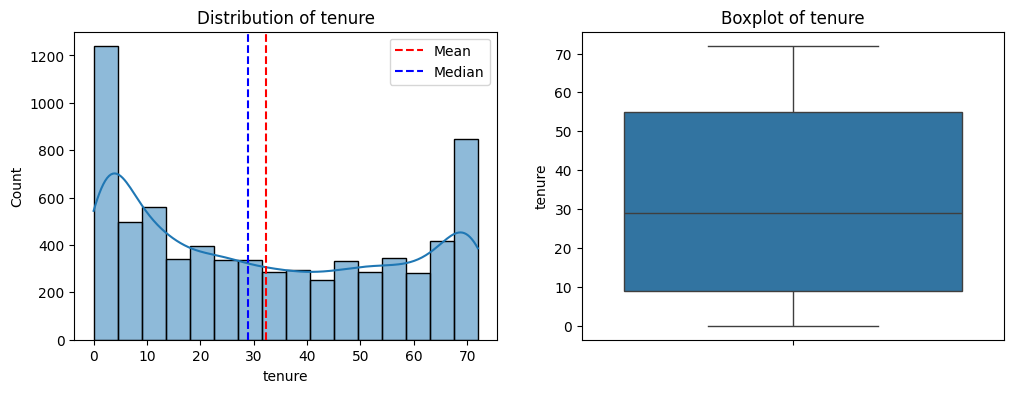

In [302]:
plot_distribution(df, 'tenure')

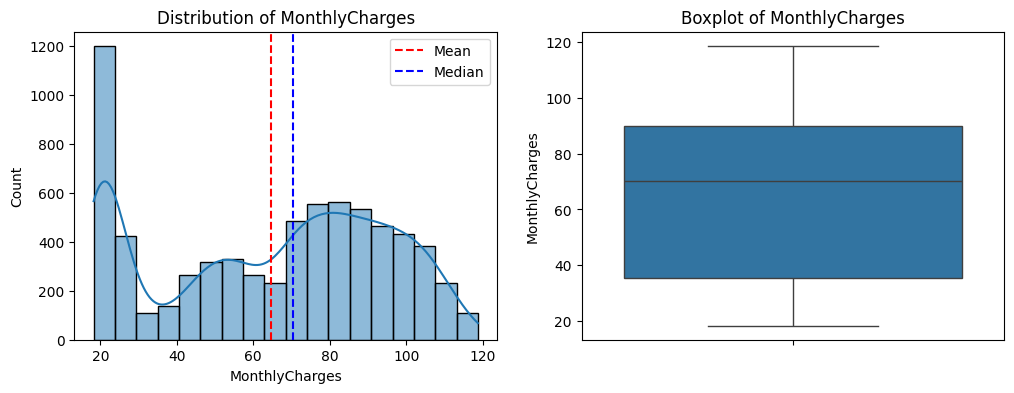

In [303]:
plot_distribution(df, "MonthlyCharges")

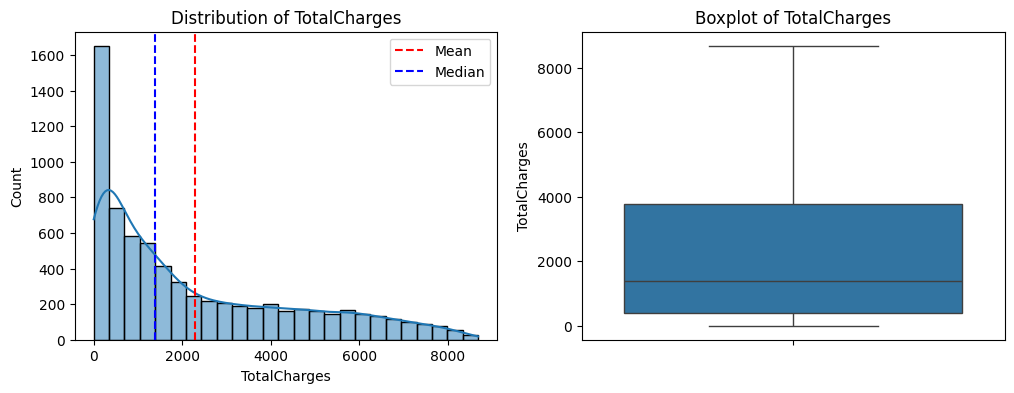

In [304]:
plot_distribution(df, "TotalCharges")
## right skewed

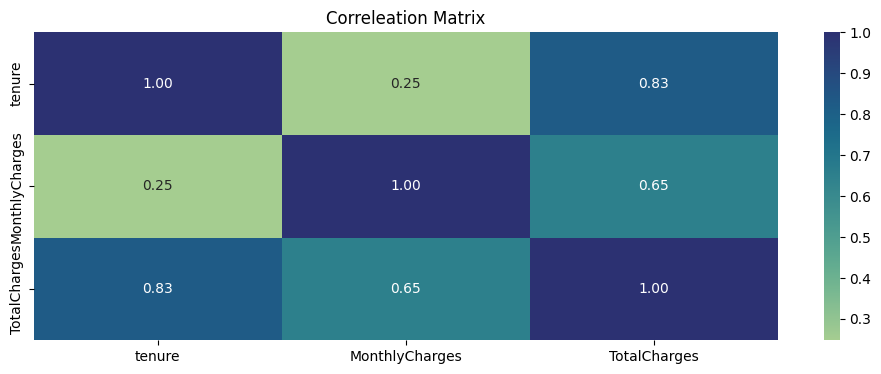

In [305]:
plt.figure(figsize=(12, 4))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True,cmap='crest', fmt='.2f')
plt.title("Correleation Matrix")
plt.show()

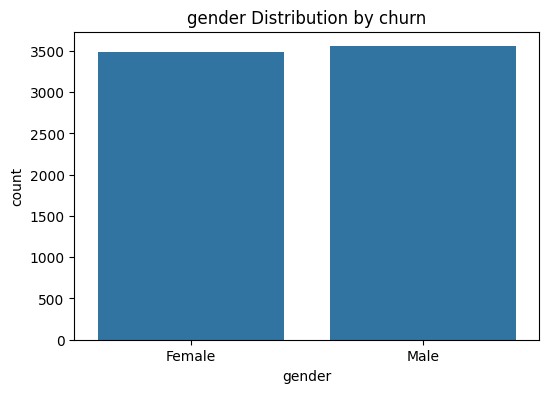

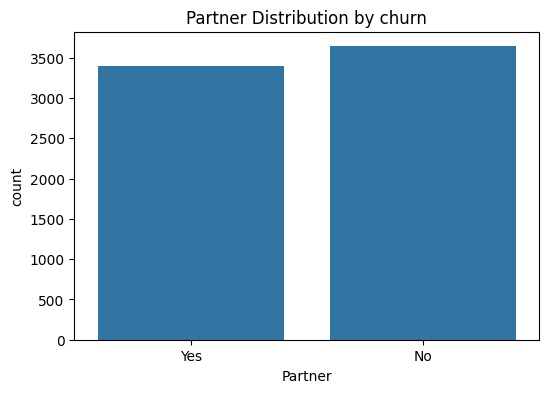

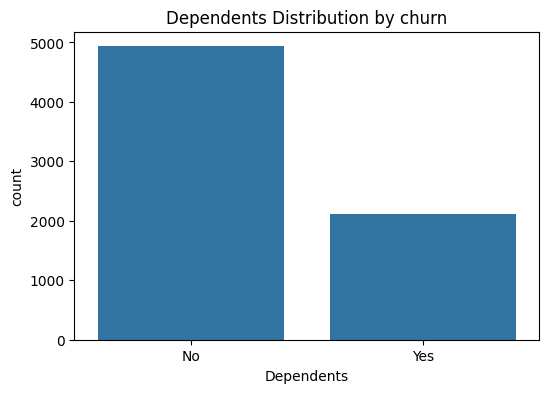

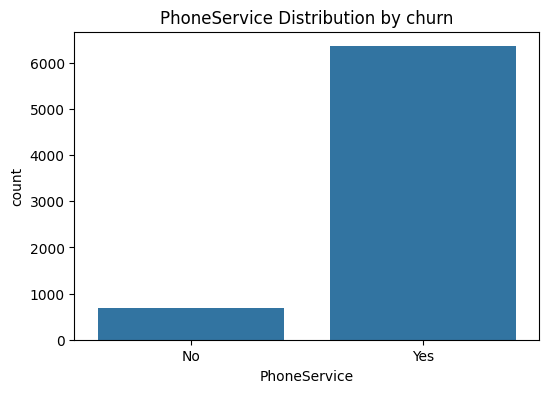

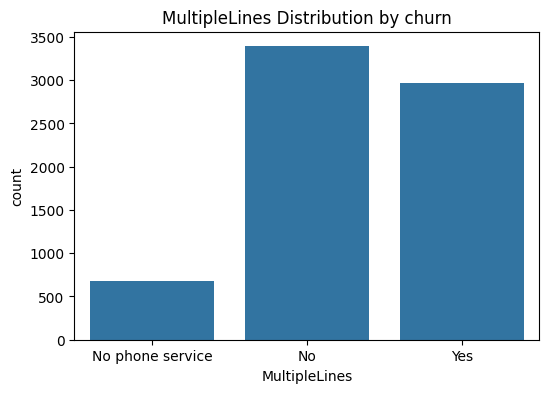

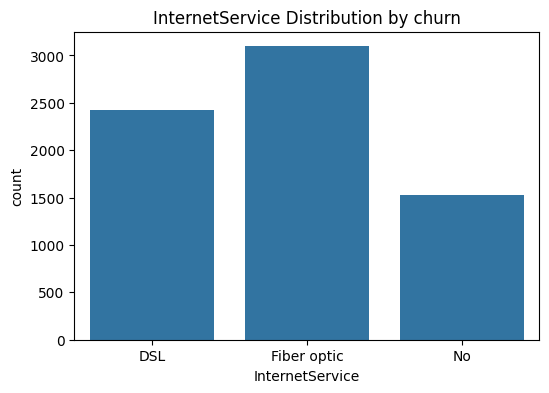

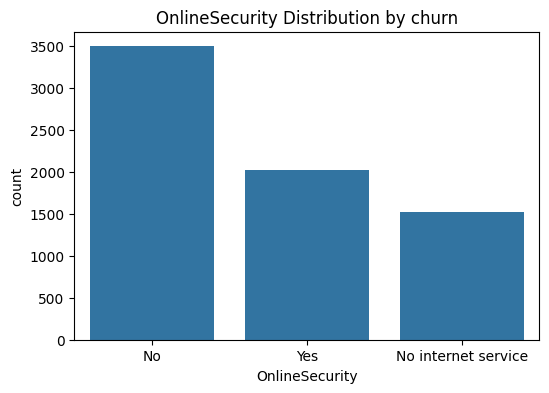

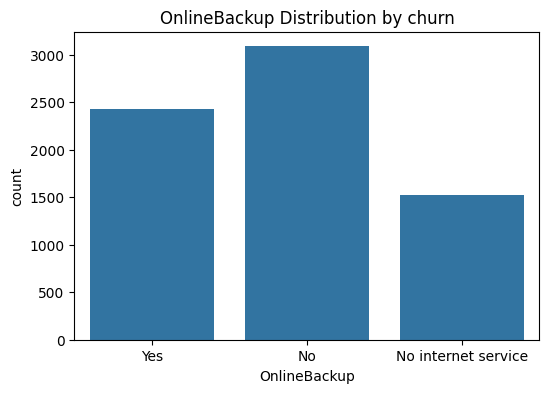

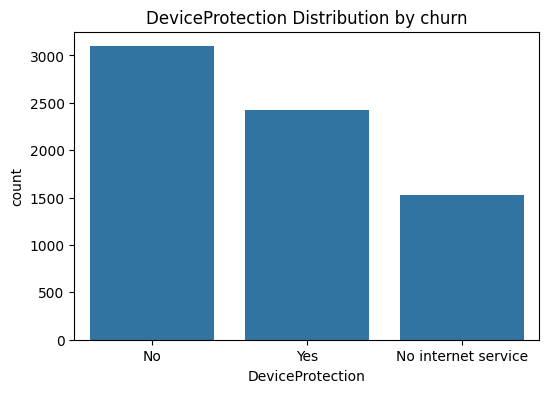

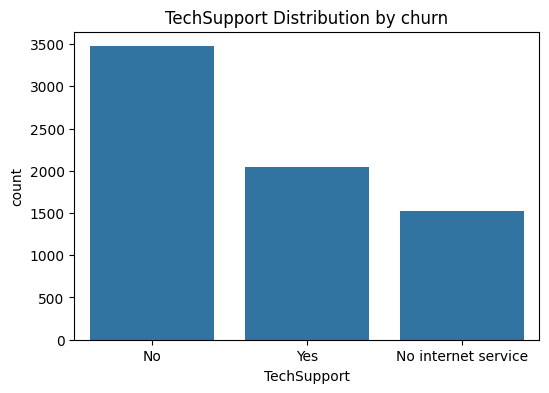

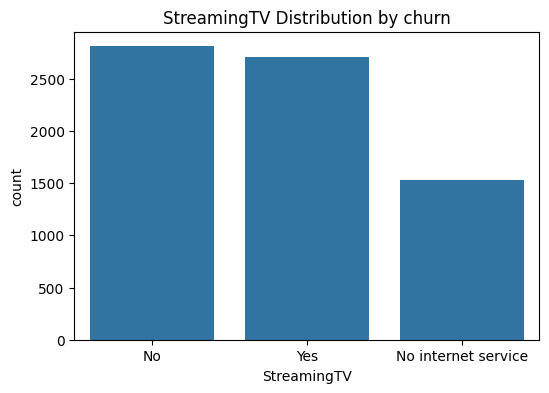

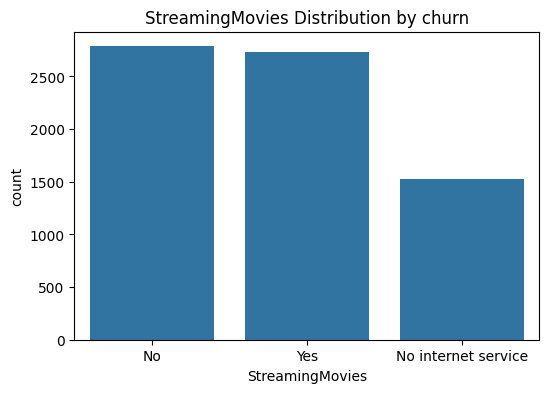

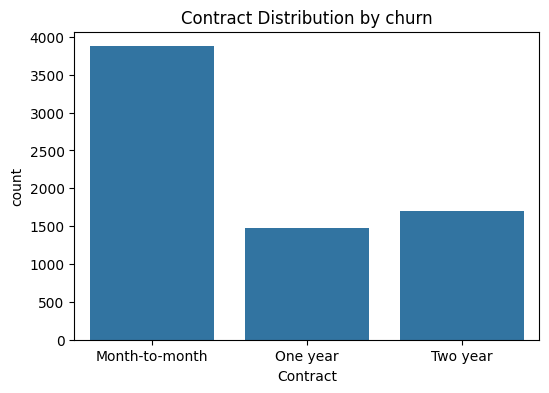

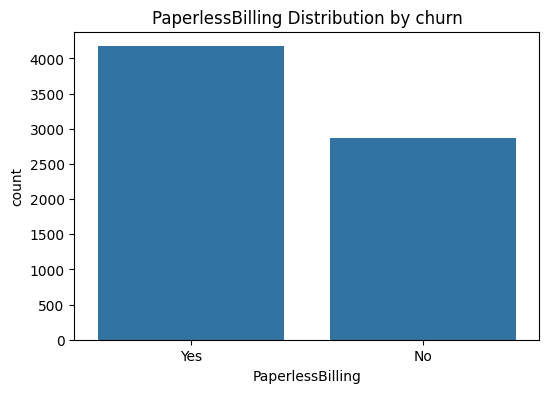

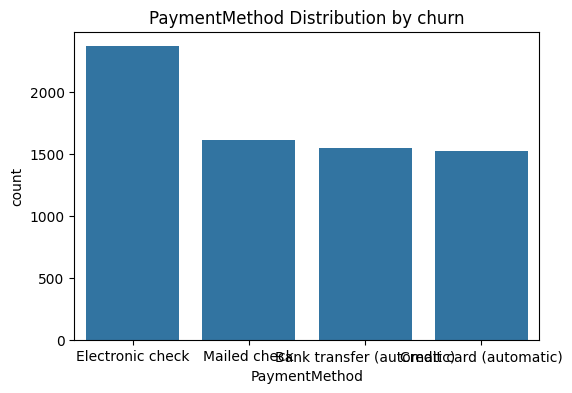

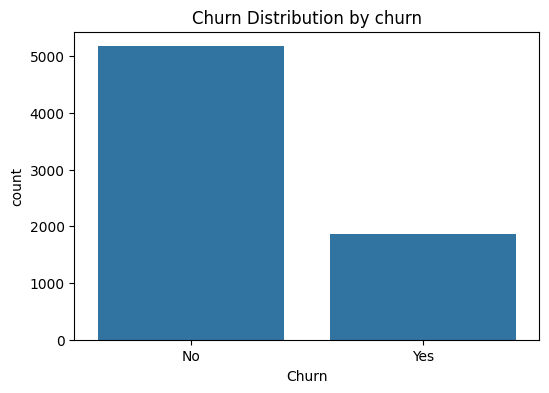

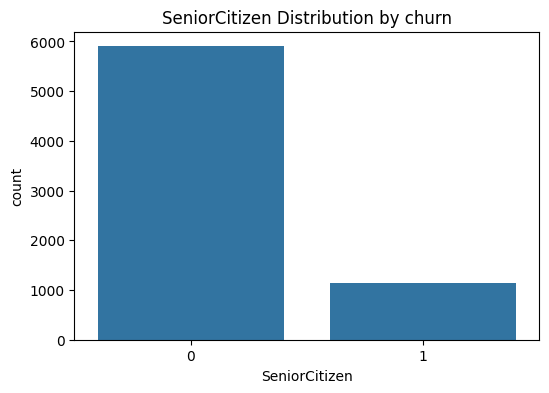

In [306]:
categorical_cols = df.select_dtypes(exclude='number')

categorical_cols = categorical_cols.columns.tolist() + ['SeniorCitizen']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col])
    plt.title(f"{col} Distribution by churn")
    plt.show()

## 4- Data Preprocessing

In [307]:
# Label Encoder
df.Churn = df.Churn.replace({'Yes': 1 , 'No':0})

/var/folders/m2/c4gwpmp11dl6fhjw81j1xbf00000gp/T/ipykernel_90633/627727011.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Churn = df.Churn.replace({'Yes': 1 , 'No':0})


In [308]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,-1.277445,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,-1.160323,-0.992611,0
1,Male,0,No,No,0.066327,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,-0.259629,-0.172165,0
2,Male,0,No,No,-1.236724,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,-0.362660,-0.958066,1
3,Male,0,No,No,0.514251,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),-0.746535,-0.193672,0
4,Female,0,No,No,-1.236724,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0.197365,-0.938874,1


In [309]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler,f)

In [310]:
# Select categorical columns
cat_columns = df.select_dtypes(include=['object']).columns

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

# Fit and transform on categorical columns
encoded_features = encoder.fit_transform(df[cat_columns])  # Now a dense NumPy array

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded_features, 
    columns=encoder.get_feature_names_out(cat_columns), 
    index=df.index
)

# Drop original categorical columns and concatenate
df_encoded = df.drop(columns=cat_columns).join(encoded_df)

df_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,-1.160323,-0.992611,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,0.066327,-0.259629,-0.172165,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,-1.236724,-0.362660,-0.958066,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,0.514251,-0.746535,-0.193672,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,-1.236724,0.197365,-0.938874,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [311]:
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [312]:
'''
When to Use StandardScaler?
✅ Use StandardScaler when:

Features follow a Gaussian (normal) distribution
You're using algorithms that are sensitive to scale (SVM, KNN, PCA, Linear Regression, Neural Networks)
❌ Don't use StandardScaler when:

You have categorical data (use one-hot encoding instead)
The model is tree-based (Decision Trees, Random Forest, XGBoost) → They don't require scaling
'''


"\nWhen to Use StandardScaler?\n✅ Use StandardScaler when:\n\nFeatures follow a Gaussian (normal) distribution\nYou're using algorithms that are sensitive to scale (SVM, KNN, PCA, Linear Regression, Neural Networks)\n❌ Don't use StandardScaler when:\n\nYou have categorical data (use one-hot encoding instead)\nThe model is tree-based (Decision Trees, Random Forest, XGBoost) → They don't require scaling\n"

In [313]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,-1.160323,-0.992611,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,0.066327,-0.259629,-0.172165,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,-1.236724,-0.362660,-0.958066,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,0.514251,-0.746535,-0.193672,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,-1.236724,0.197365,-0.938874,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


### Train Test Split

In [314]:
X = df_encoded.drop(columns='Churn')
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

y_train.value_counts()

Churn
0    3635
1    1295
Name: count, dtype: int64

### Over Sampling

In [315]:
# OverSampling

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

## 5- Model Training

In [316]:
models= {
    'Random Forest': RandomForestClassifier(n_estimators=50,random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
}

In [317]:
hyperparams = {
    'Random Forest':{
        'n_estimators': [50,100,150,200],
        'max_depth': [5,10,15,20]
    },
    'XGBoost':{
        'learning_rate': [0.01, 0.02, 0.1, 0.2],
        'max_depth':[3,5,7,9]
    }
}

In [318]:
# Train model with default hyperparameters
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.7761476573592049


In [319]:
# Tuning 
best_models = {}

for model_name, model in models.items():
    print(f"Tuning {model_name} ... ")
    grid = GridSearchCV(estimator=model, param_grid=hyperparams[model_name], cv=3, scoring='accuracy')
    grid.fit(X_train_smote,y_train_smote)

    best_models[model_name] = grid.best_estimator_

    print(f"Best params for {model_name} : {grid.best_params_}")
    print(f"Best Accuracy for {model_name} : {grid.best_score_: 0.2f}")



Tuning Random Forest ... 
Best params for Random Forest : {'max_depth': 20, 'n_estimators': 200}
Best Accuracy for Random Forest :  0.85
Tuning XGBoost ... 
Best params for XGBoost : {'learning_rate': 0.1, 'max_depth': 9}
Best Accuracy for XGBoost :  0.83


In [320]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_models['Random Forest'],f)


In [321]:
x_test_pred = best_models['Random Forest'].predict(X_test)
x_test_prob = best_models['Random Forest'].predict_proba(X_test)[:,1]



In [322]:
x_test_pred

array([1, 0, 0, ..., 0, 0, 0])

In [323]:
x_test_prob

array([0.74812354, 0.125     , 0.01      , ..., 0.025     , 0.40604971,
       0.23225   ])

In [324]:
print(f"Accuracy : {accuracy_score(y_test,x_test_pred)}")
print(f"ROC - AUC Score : {roc_auc_score(y_test,x_test_pred)}")
print(f"Confusion Matrix : \n{confusion_matrix(y_test,x_test_pred)}")
print(f"Classification Report : \n{classification_report(y_test,x_test_pred)}")

Accuracy : 0.7813535257927118
ROC - AUC Score : 0.7199083979143884
Confusion Matrix : 
[[1315  224]
 [ 238  336]]
Classification Report : 
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1539
           1       0.60      0.59      0.59       574

    accuracy                           0.78      2113
   macro avg       0.72      0.72      0.72      2113
weighted avg       0.78      0.78      0.78      2113



In [325]:
### Load data

import joblib

def load_model(model_name):
    """
    Load a trained model from a file.
    
    Parameters:
    model_name (str): Path to the saved model file.
    
    Returns:
    Loaded model object.
    """
    try:
        model = joblib.load(model_name)
        print(f"Model '{model_name}' loaded successfully.")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None
    

prediction_model = load_model("best_model.pkl")
encoder_model = load_model("encoder.pkl")
scaler_model = load_model("scaler.pkl")




Model 'best_model.pkl' loaded successfully.
Model 'encoder.pkl' loaded successfully.
Model 'scaler.pkl' loaded successfully.


In [326]:
def make_prediciton(input_data):
    input_df = pd.DataFrame([input_data])
    
    cat_columns = input_df.select_dtypes(include=['object']).columns

    # Fit and transform on categorical columns
    encoded_features = encoder_model.transform(input_df[cat_columns])

    # Convert to DataFrame
    encoded_df = pd.DataFrame(
        encoded_features, 
        columns=encoder.get_feature_names_out(cat_columns), 
        index=input_df.index
    )

    # Drop original categorical columns and concatenate
    df_encoded = input_df.drop(columns=cat_columns).join(encoded_df)

    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    df_encoded[numerical_cols] = scaler_model.fit_transform(df_encoded[numerical_cols])

    prediction = prediction_model.predict(df_encoded)[0]
    probabilty = prediction_model.predict_proba(df_encoded)[0,1]

    return f"Churn with probabilty {probabilty}" if prediction == 1 else f"No Churn with probabilty {probabilty}"
    

In [327]:
example_input = {
    'gender':'Female',
    'SeniorCitizen':0,
    'Partner': 'Yes',
    'Dependents':'No',
    'tenure':1,
    'PhoneService':'No',
    'MultipleLines':'No phone services',
    'InternetService':'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection':'No',
    'TechSupport':'No',
    'StreamingTV':'No',
    'StreamingMovies':'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling':'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges':29.85

}

res = make_prediciton(example_input)

res

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


'No Churn with probabilty 0.3681481481481481'